# Greenland Student Kramers M4 research workflow

This notebook is the interactive index of the M4 study. It follows the same
order as the previous project: simulation validation, real-data fitting,
predictive diagnostics, bootstrap uncertainty, and IOS goodness-of-fit.

Long calculations are run by command modules and saved as checkpoints. The
cells below load the versioned report snapshot and call reusable plotting
functions.


## Evidence status

- **Current evidence** uses the globally feasible Cholesky M4 optimizer.
- **Development evidence** records earlier recovery, discrimination, and
  M3-null bootstrap runs made before the Cholesky parameterization.

Development results explain what was tried and what must be rerun. They are
not combined with the current M4 likelihood contrast.


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

ROOT = Path.cwd()
if not (ROOT / "pyproject.toml").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from greenland_application.data_loading import load_real_data
from greenland_application.figures import (
    plot_discrimination,
    plot_ios_numerical_diagnostics,
    plot_ios_overview,
    plot_ios_phase_space,
    plot_m4_diffusion_audit,
    plot_m4_parameter_distributions,
    plot_m4_parametric_bootstrap_diffusion,
    plot_m4_parametric_bootstrap_parameters,
    plot_modelwise_ios_bootstrap,
    plot_nested_bootstrap,
    plot_predictive_densities,
    plot_predictive_percentiles,
    plot_real_data_mechanisms,
    plot_real_data_state_space,
    plot_recovery_study,
    plot_transition_improvement,
    plot_waiting_time_comparison,
)
from student_kramers import config
from student_kramers.models import PARAM_NAMES

CURRENT = ROOT / "docs" / "results" / "current"
DEVELOPMENT = ROOT / "docs" / "results" / "development"


/Users/sal/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [2]:
_, age, x, data = load_real_data()
fits = pd.read_csv(CURRENT / "model_fits.csv")
m4_params = fits.loc[fits["model"] == "M4", PARAM_NAMES].iloc[0].to_numpy(float)
fits[["model", "nll", "aic", "bic", "q_min_global", "q_min_observed"]]


,model,nll,aic,bic,q_min_global,q_min_observed
0,M2,8524.347708,17060.695416,17095.637291,4176.668090,4176.668090
1,M3,8524.058929,17064.117858,17110.707026,4167.946212,4167.946212
2,M4,8499.311650,17020.623299,17084.683404,0.000276,3867.032067


## 1. Data and observation scheme

Only the climate coordinate \(X\) is observed. The partial likelihood uses

$$
\widehat V_k = \frac{X_{k+1}-X_k}{h}, \qquad h=0.02\ \mathrm{kyr}.
$$

The following figure shows the time series, reconstructed velocity, observed
phase space, and where M4 changes diffusion relative to M3.


/Users/sal/Desktop/Statistic Project/student-kramers-m4/greenland_application/figures.py:40: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


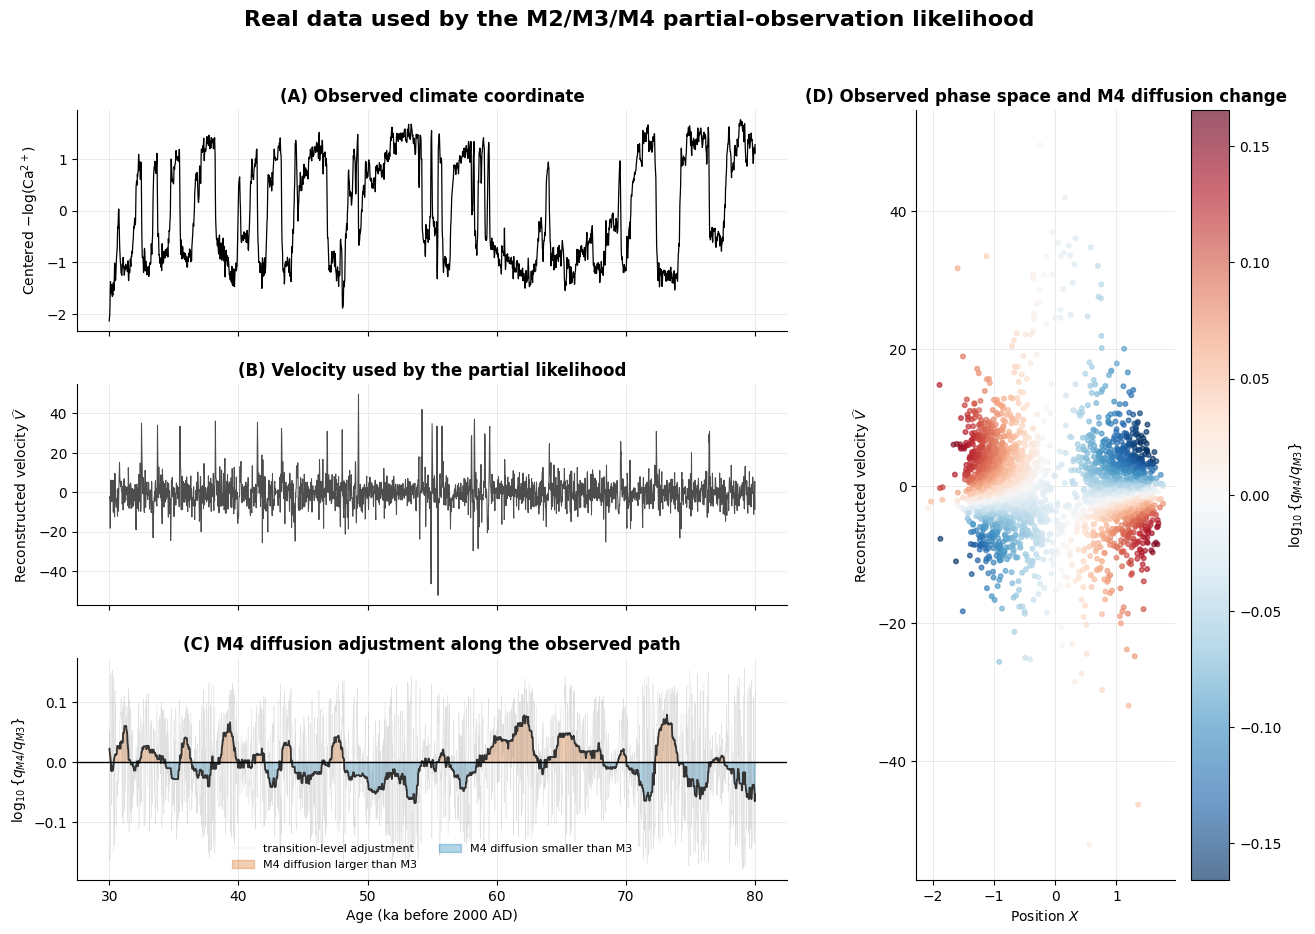

In [3]:
plot_real_data_state_space(age, x, data, fits)
plt.show()


## 2. Simulation validation

The original simulation programme contained:

1. complete-data recovery using latent \((X,V)\);
2. partial-data recovery after discarding \(V\) and reconstructing
   \(\widehat V\);
3. repeated M2, M3, and M4 recovery;
4. M3/M4 discrimination under M3 and weak, moderate, and strong M4 truth.

The saved studies below used the pre-Cholesky M4 optimizer. They are retained
as development evidence and must be rerun before they support a final
methodological claim.


In [4]:
recovery = []
for model in ("M2", "M3", "M4"):
    table = pd.read_csv(DEVELOPMENT / f"{model.lower()}_recovery_study.csv")
    table["model"] = model
    recovery.append(table)
recovery = pd.concat(recovery, ignore_index=True)
recovery.groupby(["model", "observation"]).agg(
    n=("success", "size"),
    success_rate=("success", "mean"),
    median_q_relative_rmse=("q_path_relative_rmse", "median"),
    median_seconds=("time_sec", "median"),
)


n  success_rate  median_q_relative_rmse  median_seconds
model observation                                                          
M2    complete     10           1.0                0.077716        1.574862
      partial      10           1.0                0.176795      103.159545
M3    complete     10           1.0                0.090369        2.573858
      partial      10           1.0                0.167363      159.628592
M4    complete     10           1.0                0.106567        7.039179
      partial      10           1.0                0.185145      421.193259

/Users/sal/Desktop/Statistic Project/student-kramers-m4/greenland_application/figures.py:677: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(
/Users/sal/Desktop/Statistic Project/student-kramers-m4/greenland_application/figures.py:709: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(


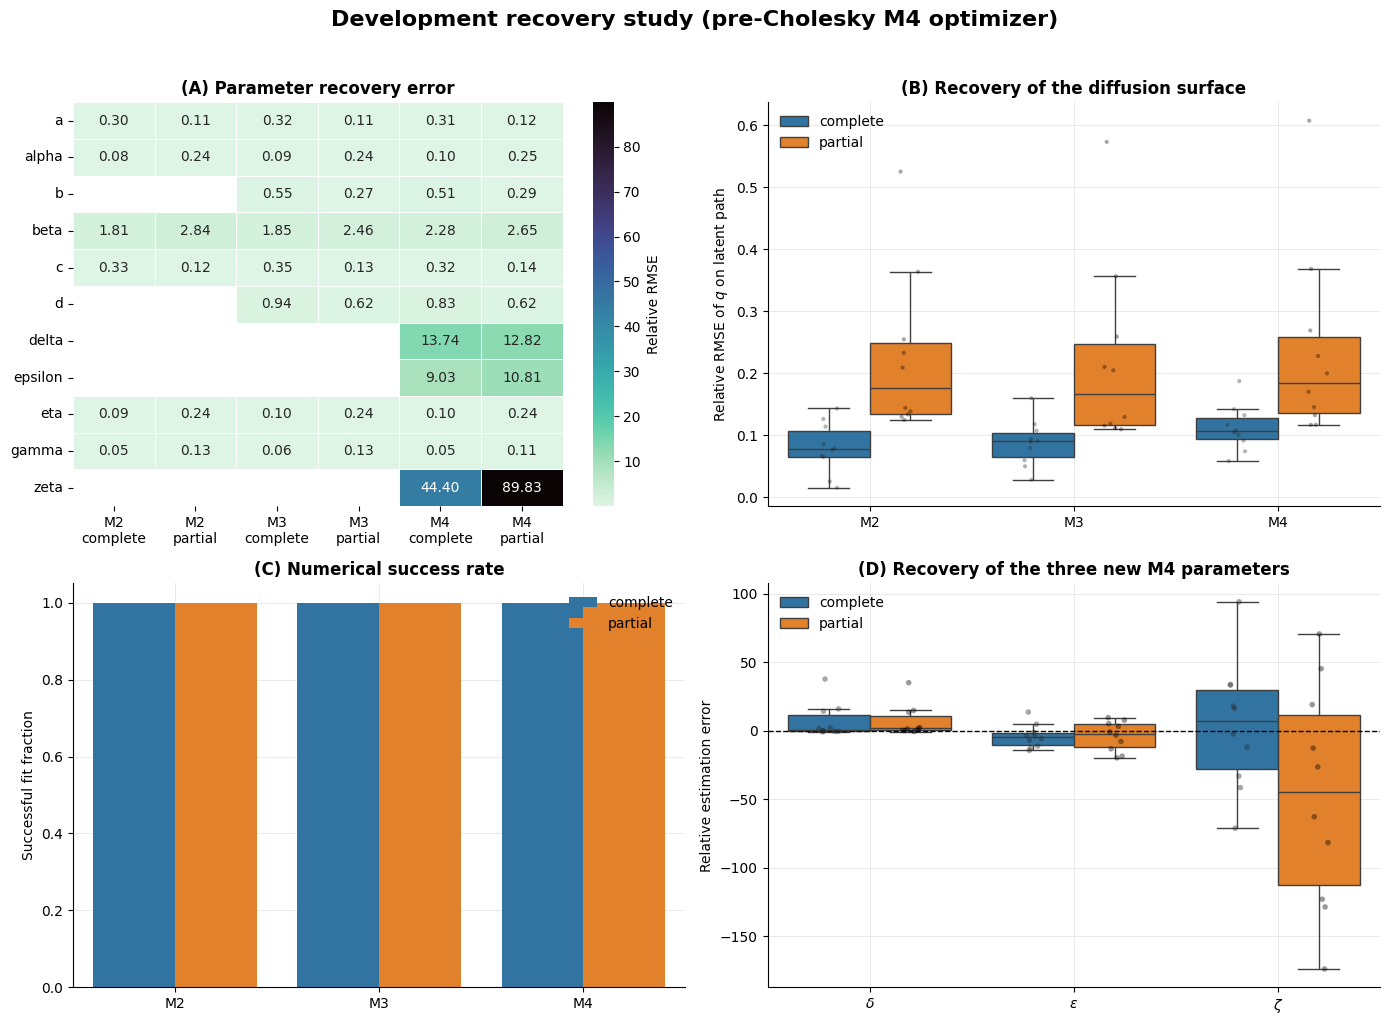

In [5]:
plot_recovery_study(
    recovery,
    config.REFERENCE_PARAMS_BY_MODEL,
    title="Development recovery study (pre-Cholesky M4 optimizer)",
)
plt.show()


In [6]:
scenarios = ("m3", "weak", "moderate", "strong")
discrimination = pd.concat(
    [pd.read_csv(DEVELOPMENT / f"discrimination_{name}.csv") for name in scenarios],
    ignore_index=True,
)
discrimination.groupby("truth").agg(
    n=("success", "size"),
    success_rate=("success", "mean"),
    median_contrast=("contrast", "median"),
    m4_win_rate=("contrast", lambda values: np.mean(values > 0)),
)


,n,success_rate,median_contrast,m4_win_rate
truth,,,,
M3,10,1.0,4.350638,1.0
moderate,10,1.0,3.808026,1.0
strong,10,1.0,15.708341,1.0
weak,10,1.0,6.740738,1.0


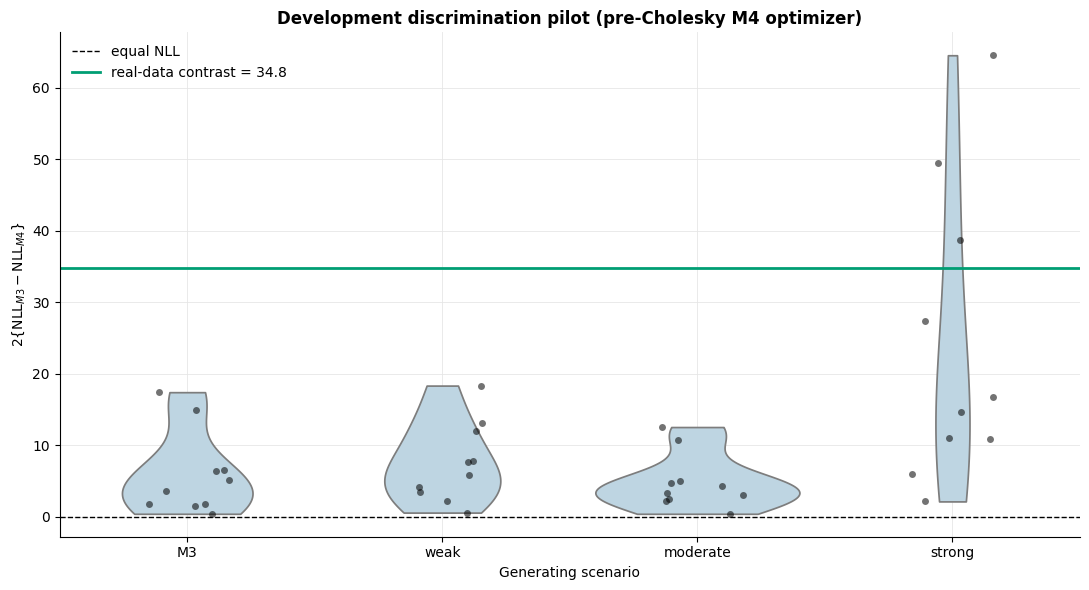

In [7]:
old_nested = pd.read_csv(DEVELOPMENT / "m3_m4_nested_summary.csv").iloc[0]
plot_discrimination(
    discrimination,
    float(old_nested["observed_contrast"]),
    title="Development discrimination pilot (pre-Cholesky M4 optimizer)",
)
plt.show()


## 3. Real-data fitting and functional comparison

M2, M3, and M4 use the same data and corrected partial-observation
pseudo-likelihood. M4 adds position-dependent diffusion:

$$
q_{M4}(x,v)
=\alpha v^2+\beta v+\gamma+\delta x^2+\epsilon xv+\zeta x.
$$


In [8]:
fits[[
    "model", "n_free", "nll", "aic", "bic",
    "q_min_global", "q_min_observed", "time_sec",
]].round(4)


,model,n_free,nll,aic,bic,q_min_global,q_min_observed,time_sec
0,M2,6,8524.3477,17060.6954,17095.6373,4176.6681,4176.6681,310.4802
1,M3,8,8524.0589,17064.1179,17110.7070,4167.9462,4167.9462,538.5079
2,M4,11,8499.3116,17020.6233,17084.6834,0.0003,3867.0321,0.2531


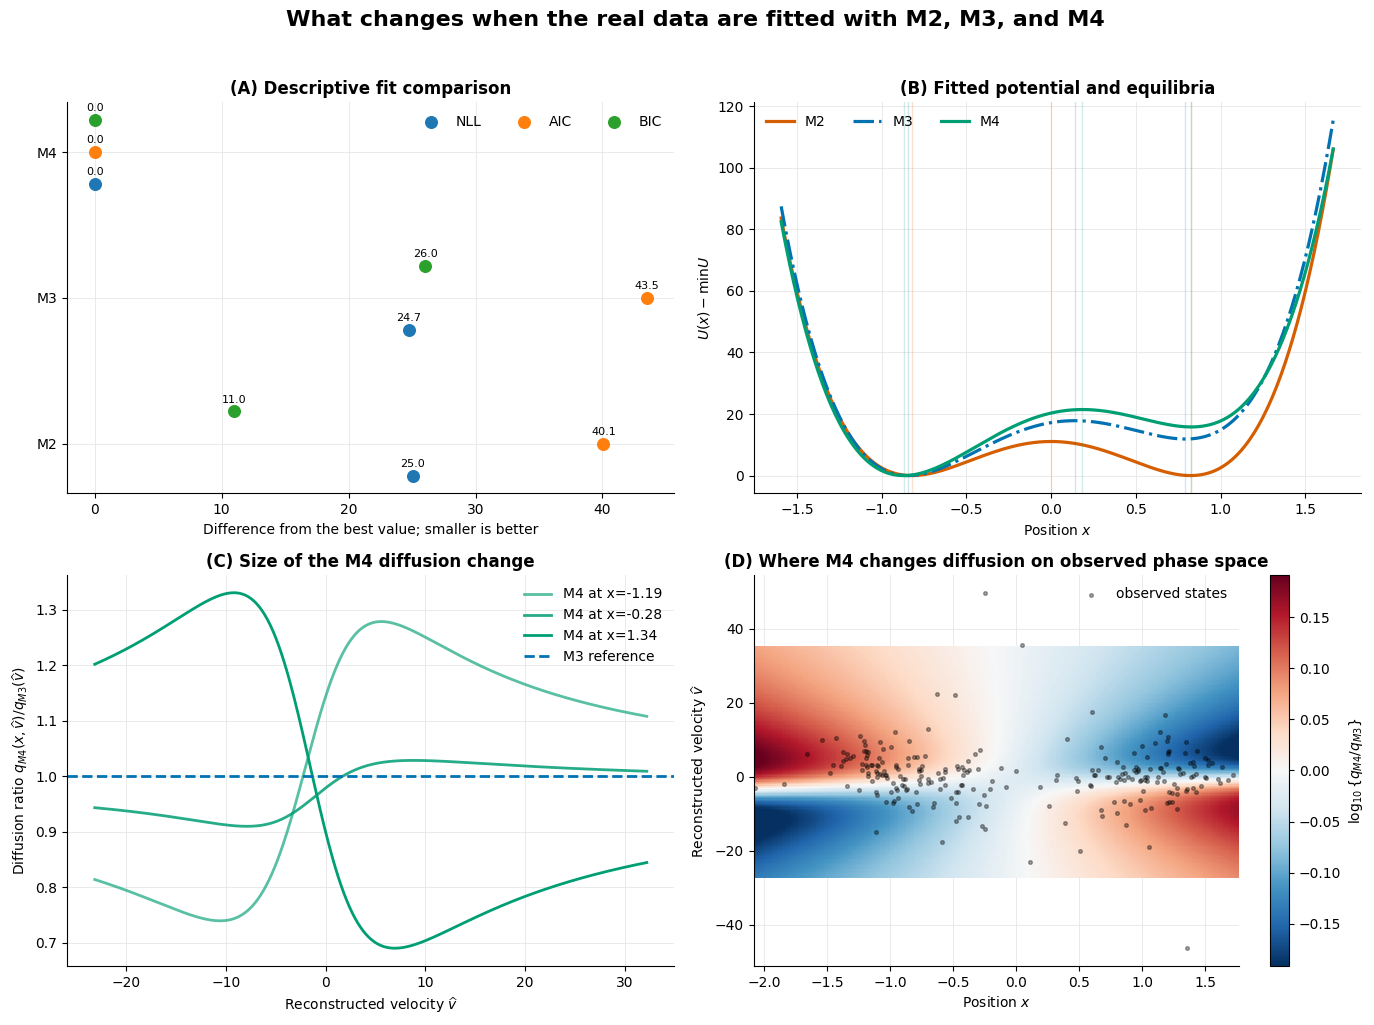

In [9]:
plot_real_data_mechanisms(fits, data)
plt.show()


## 4. Transition-level improvement and diffusion domain

The total M3-to-M4 improvement is decomposed into individual transition
contributions. A separate domain audit distinguishes the global minimum of
\(q\) from values supported by the observed state region.


In [10]:
transition = pd.read_csv(CURRENT / "transition_improvement.csv")
pd.Series({
    "NLL(M3)-NLL(M4)": transition["gain_m4_over_m3"].sum(),
    "fraction favouring M4": np.mean(transition["gain_m4_over_m3"] > 0),
    "largest positive gain": transition["gain_m4_over_m3"].max(),
    "largest negative gain": transition["gain_m4_over_m3"].min(),
})


NLL(M3)-NLL(M4)          24.747279
fraction favouring M4     0.559024
largest positive gain     5.915288
largest negative gain    -1.353872
dtype: float64

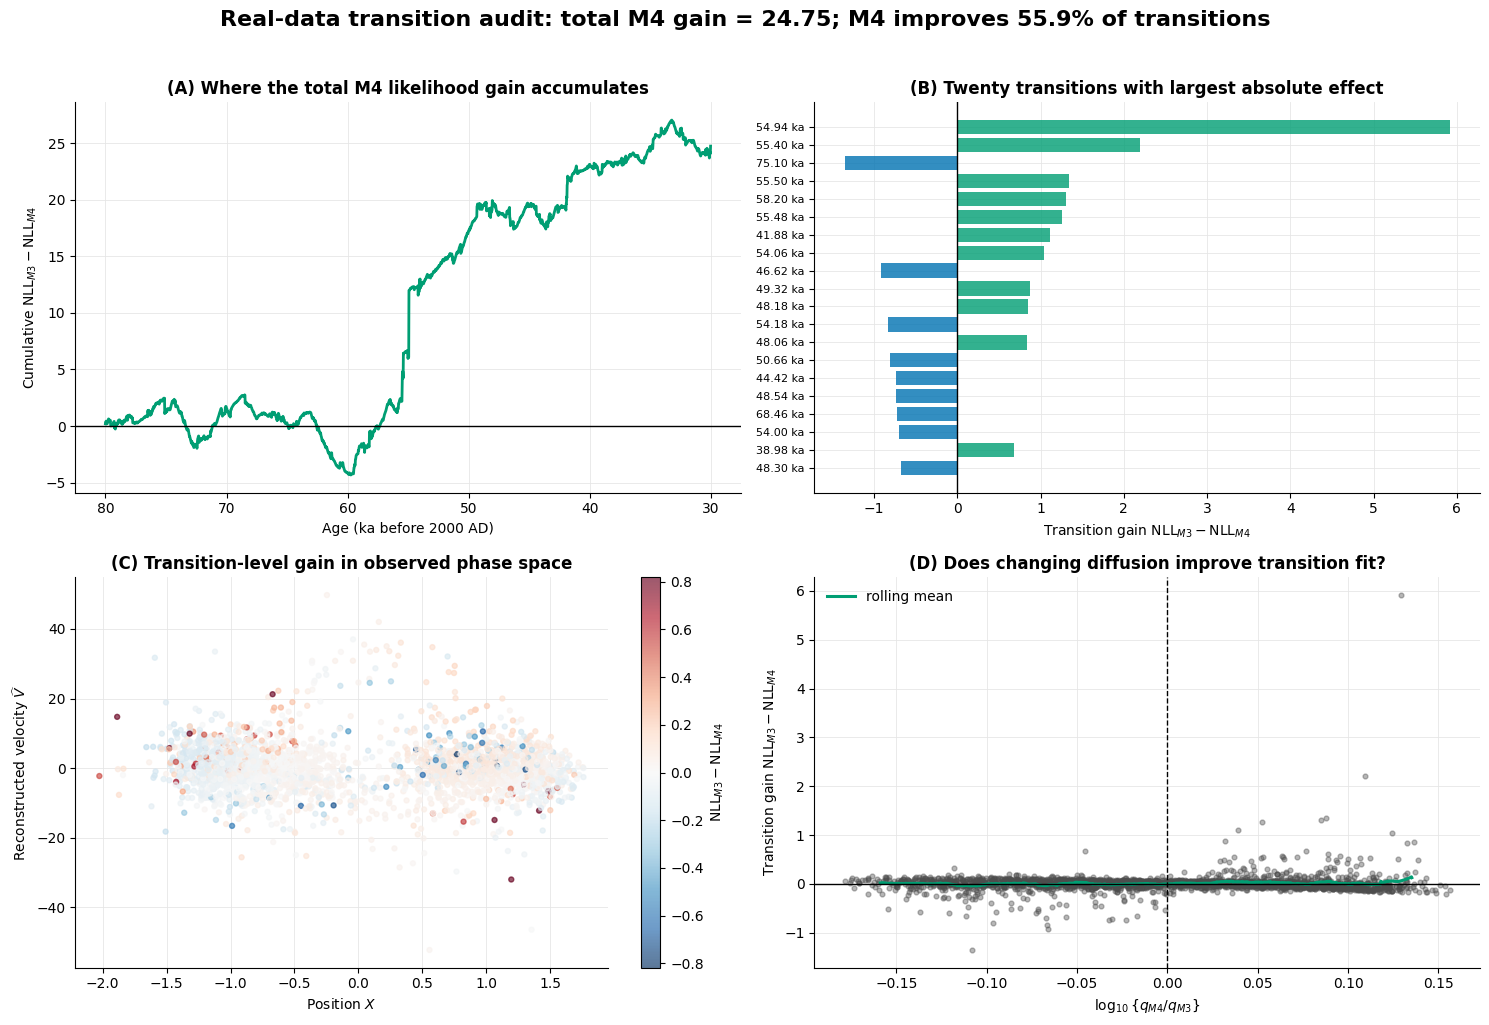

In [11]:
plot_transition_improvement(transition)
plt.show()


,model,q_min_global,q_min_observed_rectangle,q_path_min,q_min_standardized_distance
0,M2,4176.6681,4176.6681,4176.6694,0.2360
1,M3,4167.9462,4167.9462,4167.9465,0.2301
2,M4,0.0003,3867.0321,3869.1803,178.2785


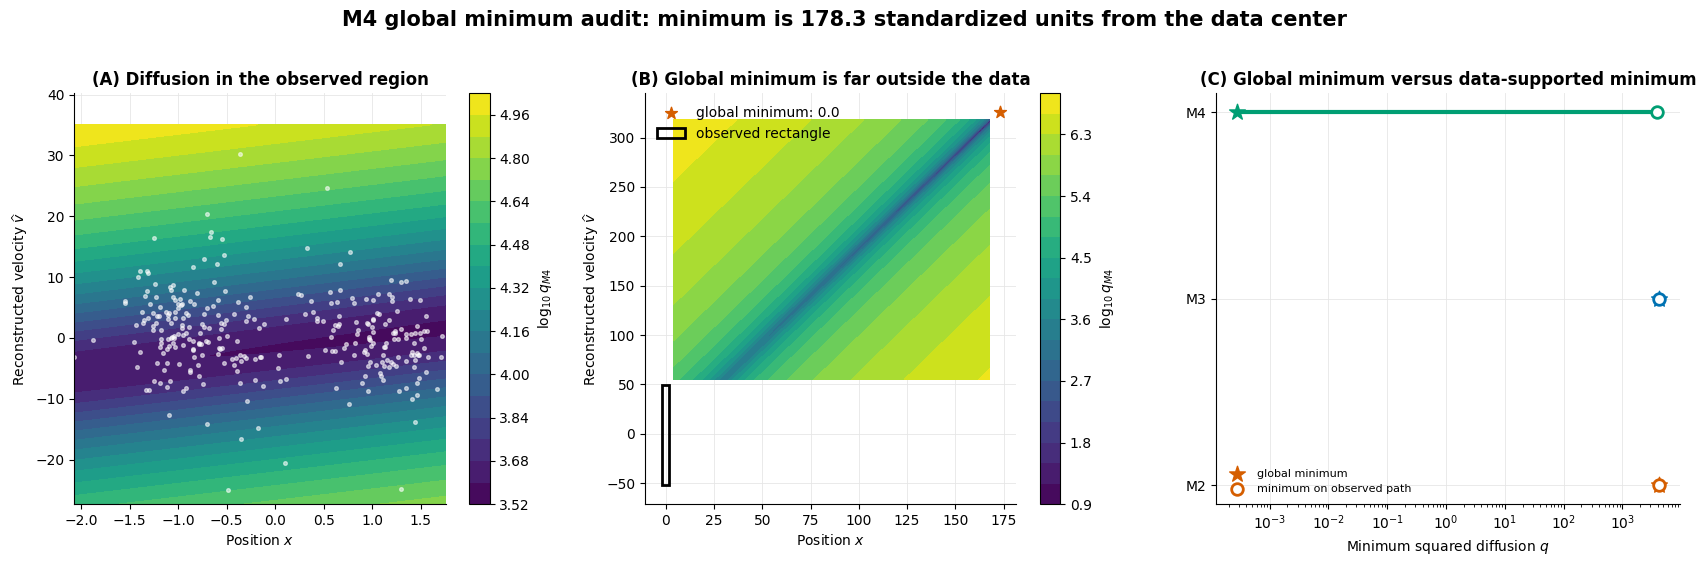

In [12]:
q_audit = pd.read_csv(CURRENT / "q_min_audit.csv")
display(q_audit[[
    "model", "q_min_global", "q_min_observed_rectangle",
    "q_path_min", "q_min_standardized_distance",
]].round(4))
plot_m4_diffusion_audit(fits, data, q_audit)
plt.show()


## 5. Predictive and regime diagnostics

For each fitted model, 100 current-fit trajectories were simulated. Their
latent velocities were discarded and reconstructed from simulated \(X\), so
the comparison uses the same observation scheme as the real data.


In [13]:
predictive = pd.read_csv(CURRENT / "predictive_comparison_summary.csv")
predictive.round(3)


,model,metric,observed,simulated_q025,simulated_median,simulated_q975,observed_percentile
0,M2,X_sd,1.001,0.765,0.853,0.928,1.00
1,M2,Vhat_sd,7.397,5.745,6.318,7.668,0.95
2,M2,lower_occupancy,0.548,0.353,0.547,0.728,0.51
3,M2,n_switches,45.000,42.475,63.500,96.150,0.08
4,M2,lower_wait_median,800.000,80.000,185.000,640.750,0.98
5,M2,upper_wait_median,520.000,80.000,205.000,740.500,0.93
6,M3,X_sd,1.001,0.707,0.851,0.952,1.00
7,M3,Vhat_sd,7.397,5.740,6.327,7.406,0.97
8,M3,lower_occupancy,0.548,0.386,0.588,0.785,0.32
9,M3,n_switches,45.000,37.950,63.500,89.050,0.13


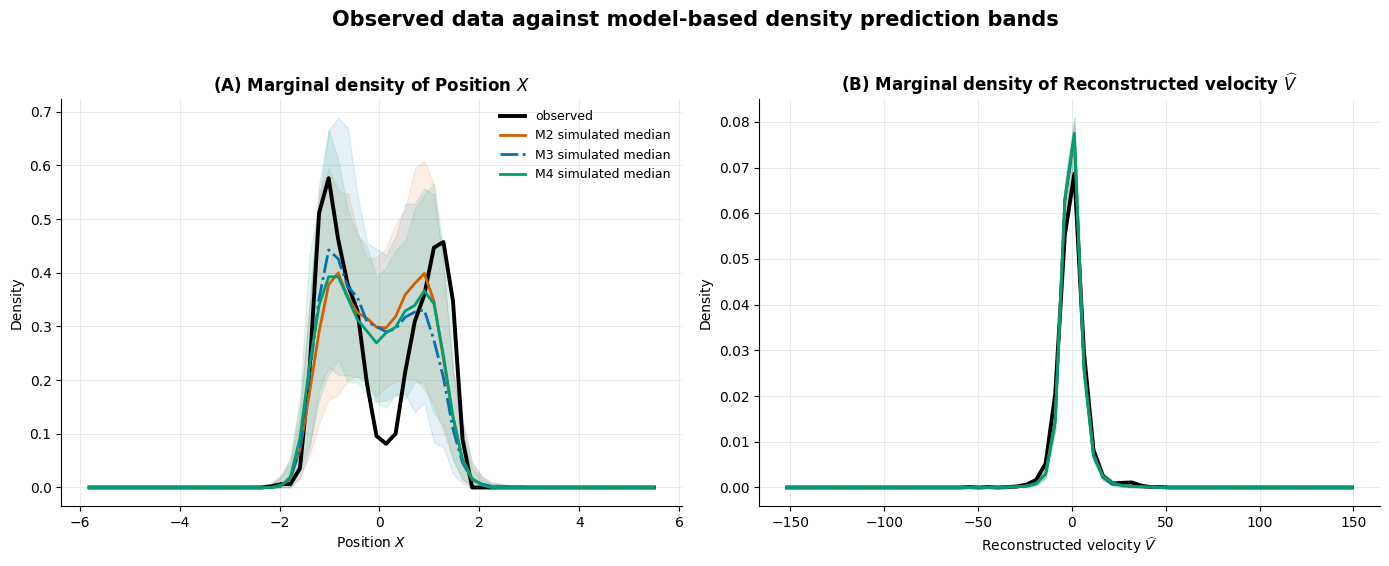

In [14]:
plot_predictive_densities(pd.read_csv(CURRENT / "predictive_density.csv"))
plt.show()


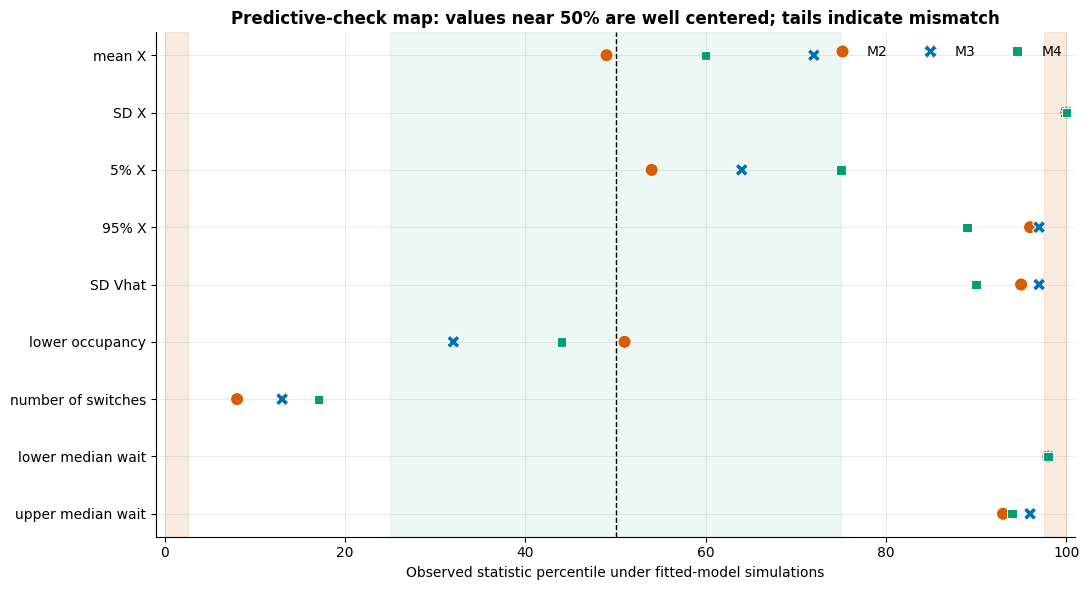

In [15]:
plot_predictive_percentiles(
    pd.read_csv(CURRENT / "predictive_summary.csv"),
    pd.read_csv(CURRENT / "predictive_behavior.csv"),
)
plt.show()


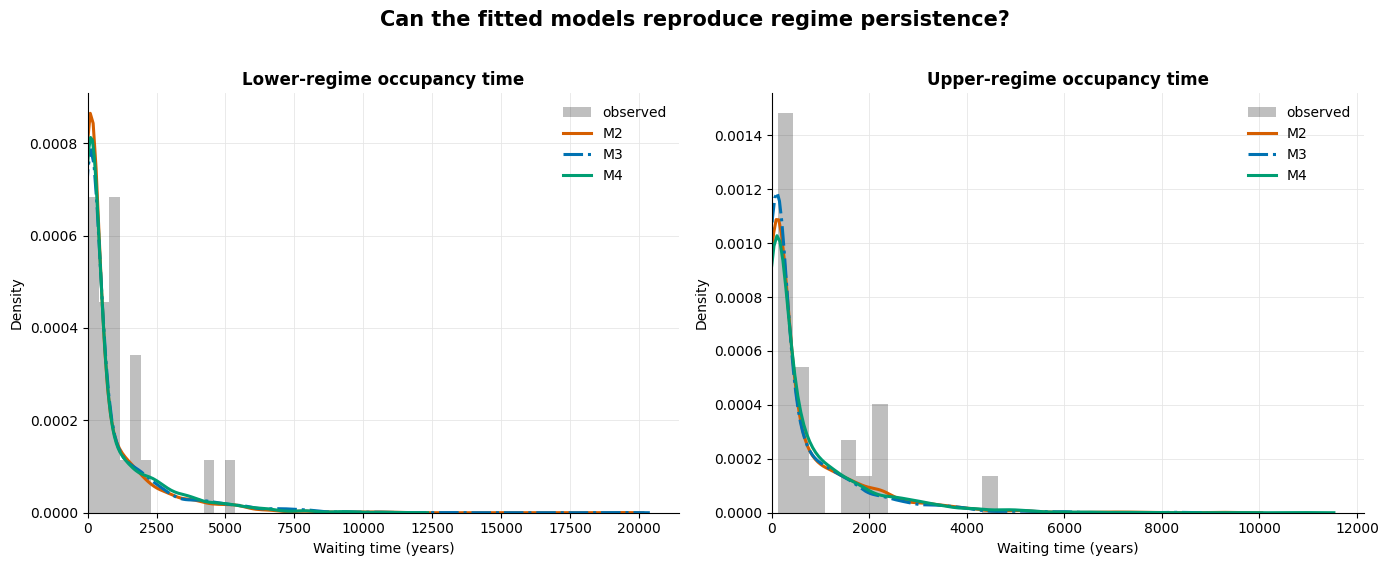

In [16]:
plot_waiting_time_comparison(pd.read_csv(CURRENT / "predictive_waiting.csv"))
plt.show()


## 6. Three bootstrap questions

The project uses three different bootstrap designs.

1. **M3-null nested bootstrap:** can M4 obtain the observed likelihood gain
   when M3 generates the data?
2. **M4 parametric bootstrap:** how uncertain are the M4 parameters and fitted
   diffusion function?
3. **M4 model-wise IOS bootstrap:** is observed leave-one-out sensitivity
   unusually large under fitted M4?

Only designs 2 and 3 use the current Cholesky optimizer. Design 1 remains a
historical diagnostic until rerun.


In [17]:
bootstrap_overview = pd.read_csv(
    CURRENT / "m4_parametric_bootstrap_overview.csv"
)
bootstrap_overview.round(4)


,n_total,n_success,n_failed,success_rate,median_time_sec,total_time_sec,nll_mean,nll_sd,nll_q025,nll_q50,nll_q975
0,500,496,4,0.992,3.23,1667.6338,8139.0294,148.247,7874.5326,8131.5965,8464.943


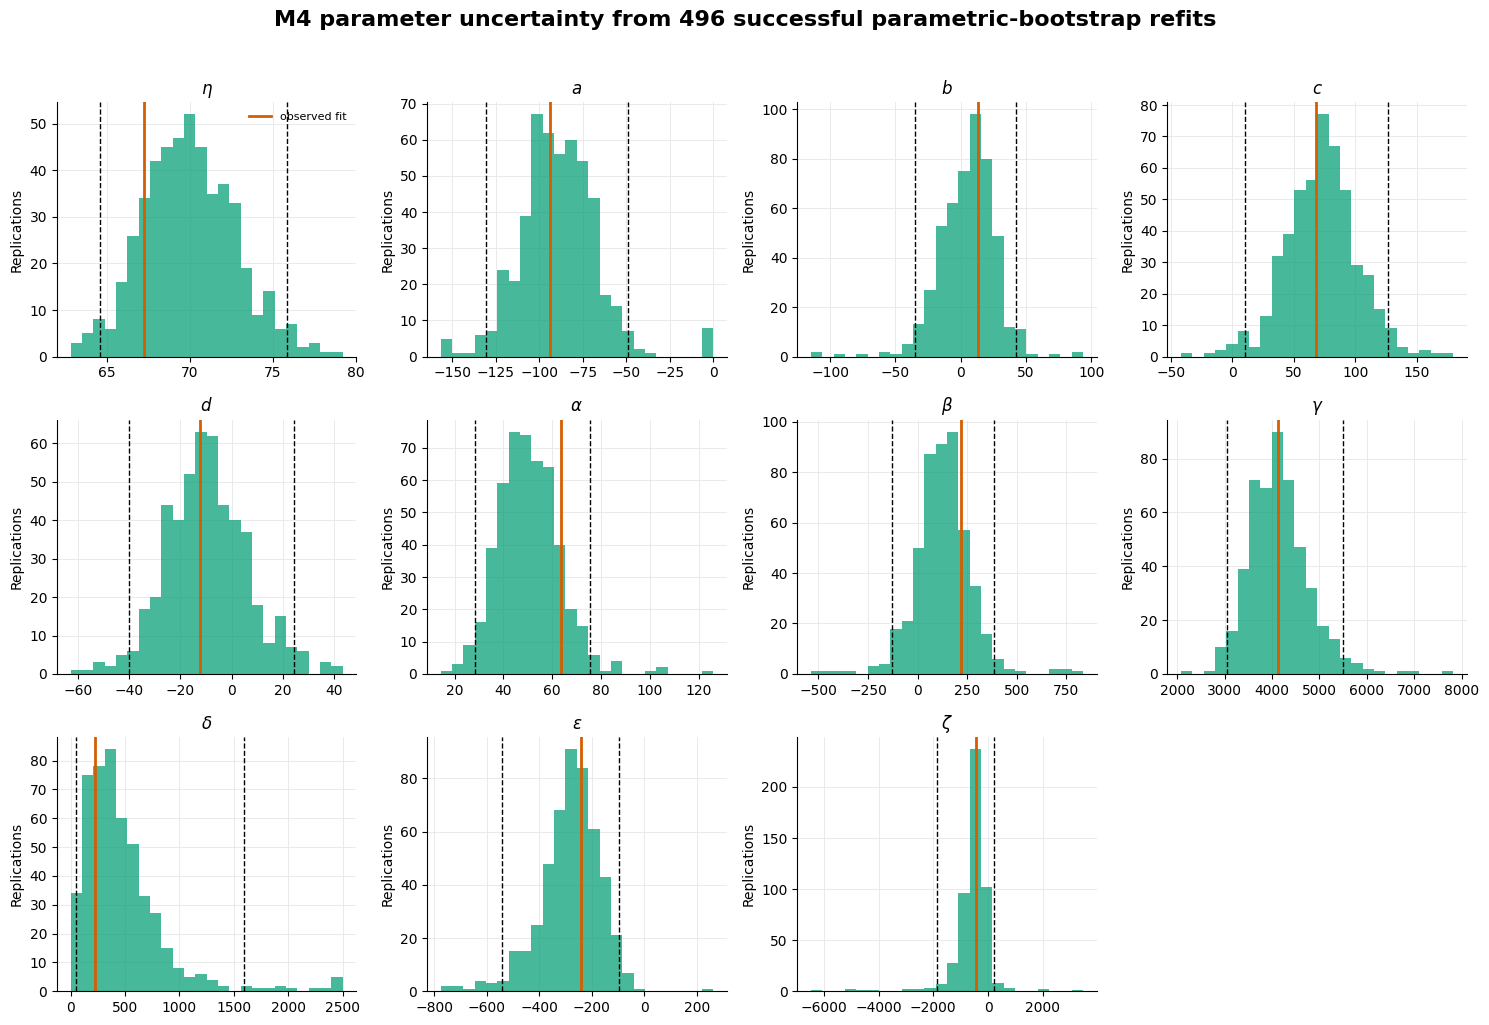

In [18]:
m4_bootstrap = pd.read_csv(CURRENT / "m4_parametric_bootstrap.csv")
plot_m4_parameter_distributions(m4_bootstrap, m4_params)
plt.show()


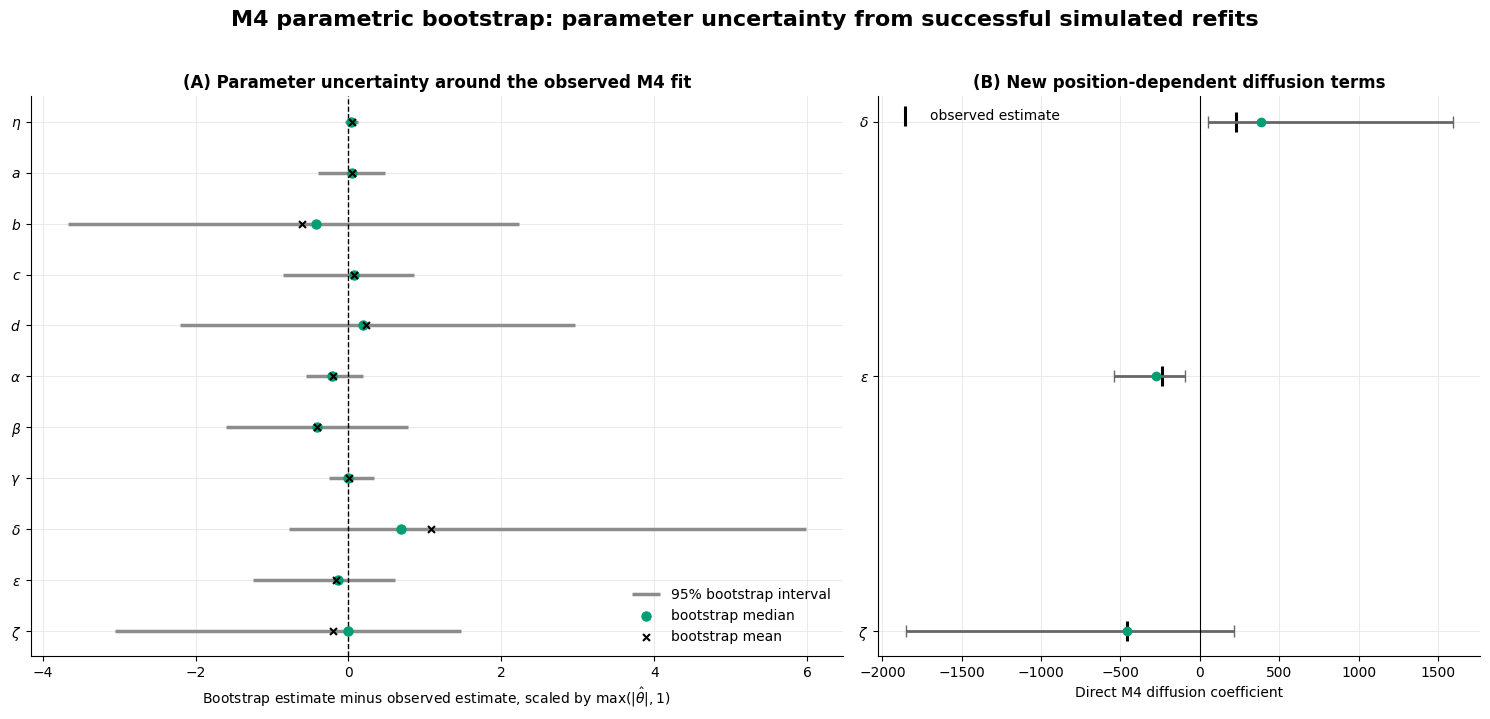

In [19]:
parameter_summary = pd.read_csv(
    CURRENT / "m4_parametric_bootstrap_parameters.csv"
)
plot_m4_parametric_bootstrap_parameters(parameter_summary)
plt.show()


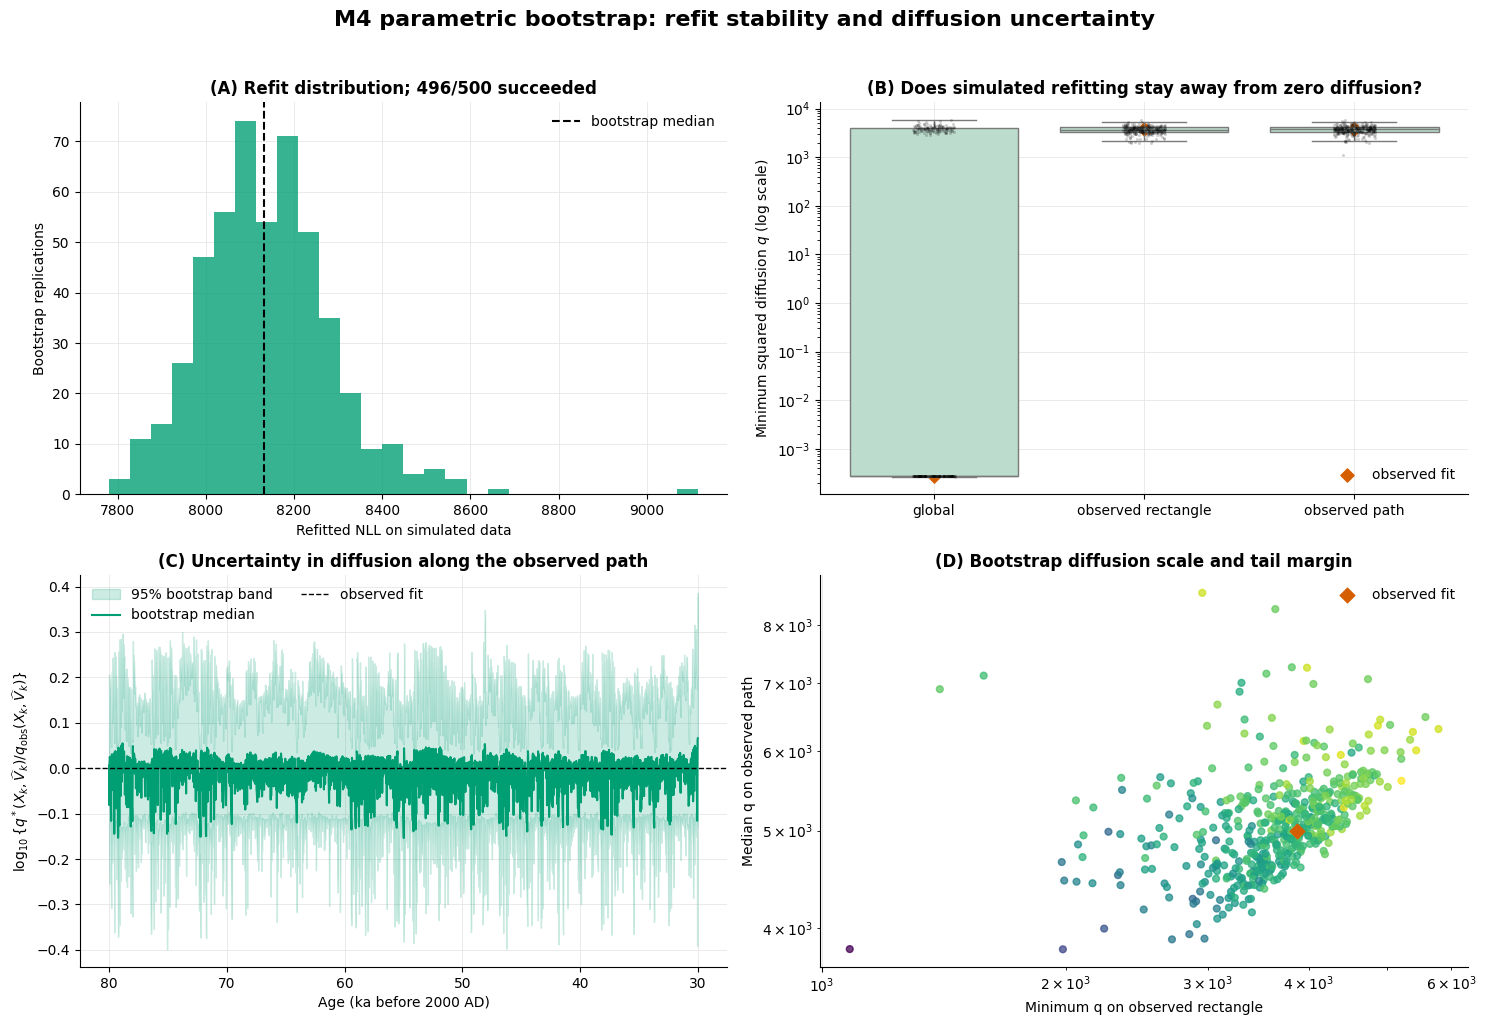

In [20]:
plot_m4_parametric_bootstrap_diffusion(
    bootstrap_overview,
    pd.read_csv(CURRENT / "m4_parametric_bootstrap_diffusion.csv"),
    pd.read_csv(CURRENT / "m4_parametric_bootstrap_diffusion_summary.csv"),
    pd.read_csv(CURRENT / "m4_parametric_bootstrap_path_band.csv"),
)
plt.show()


In [21]:
pd.read_csv(CURRENT / "m4_bootstrap_derived_summary.csv").round(4)


,metric,observed,n_finite,q025,median,q975
0,lower_well,-0.8707,417,-1.1044,-0.9421,-0.7136
1,barrier,0.1852,417,-0.3359,0.1175,0.4792
2,upper_well,0.8264,417,0.5893,0.8991,1.0812
3,Delta_U_lower,21.4602,417,2.5878,24.0083,56.9540
4,Delta_U_upper,5.6571,417,0.2134,12.2042,42.4217
5,q_min,0.0003,496,0.0003,0.0003,4801.3382
6,q_min_x,172.8843,496,-0.0557,8.4840,477.4990
7,q_min_v,325.8302,496,-0.7443,14.5297,1305.5836
8,nu_proxy,3.1187,496,2.8326,3.8230,5.8891


### Historical M3-null bootstrap

The figure below used the earlier direct-coefficient M4 optimizer and the old
observed contrast. It documents the previous calculation only. The current
contrast cannot be inserted into this old null distribution.


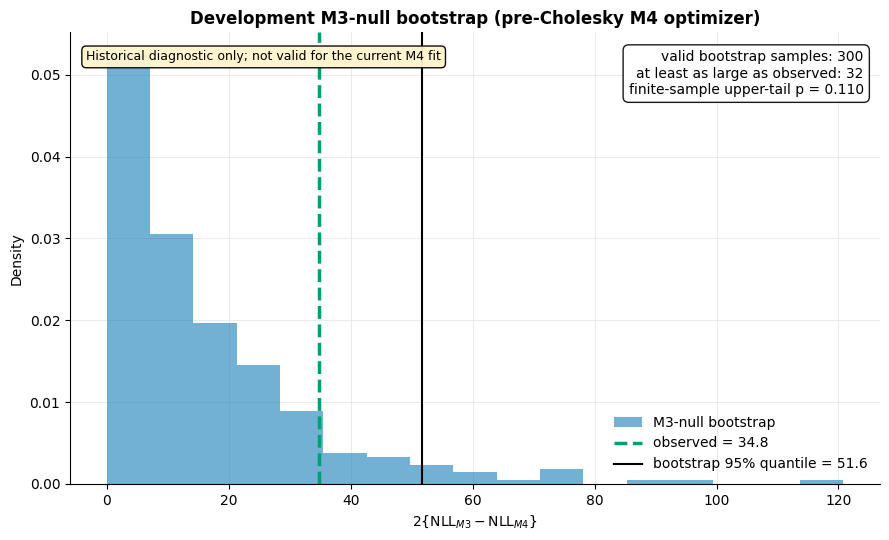

In [22]:
old_nested_table = pd.read_csv(DEVELOPMENT / "m3_m4_nested_bootstrap.csv")
plot_nested_bootstrap(
    old_nested_table,
    float(old_nested["observed_contrast"]),
    title="Development M3-null bootstrap (pre-Cholesky M4 optimizer)",
    note="Historical diagnostic only; not valid for the current M4 fit",
)
plt.show()


## 7. Exact information-omission sensitivity

For transition \(k\),

$$
\operatorname{IOS}_k
=\ell_k(\widehat\theta_{-k})-\ell_k(\widehat\theta),
\qquad
T_N=\sum_k\operatorname{IOS}_k.
$$

All 2499 transitions were recomputed for M2, M3, and M4.


In [23]:
ios_summary = pd.read_csv(CURRENT / "ios_comparison.csv")
ios_summary[[
    "model", "T_N", "n_valid", "success_rate",
    "fraction_transitions_for_80pct_positive", "total_seconds",
]].round(4)


,model,T_N,n_valid,success_rate,fraction_transitions_for_80pct_positive,total_seconds
0,M2,8.5893,2499,1.0,0.0240,123.1121
1,M3,11.5488,2499,1.0,0.0340,182.1718
2,M4,21.8765,2499,1.0,0.0864,3793.8558


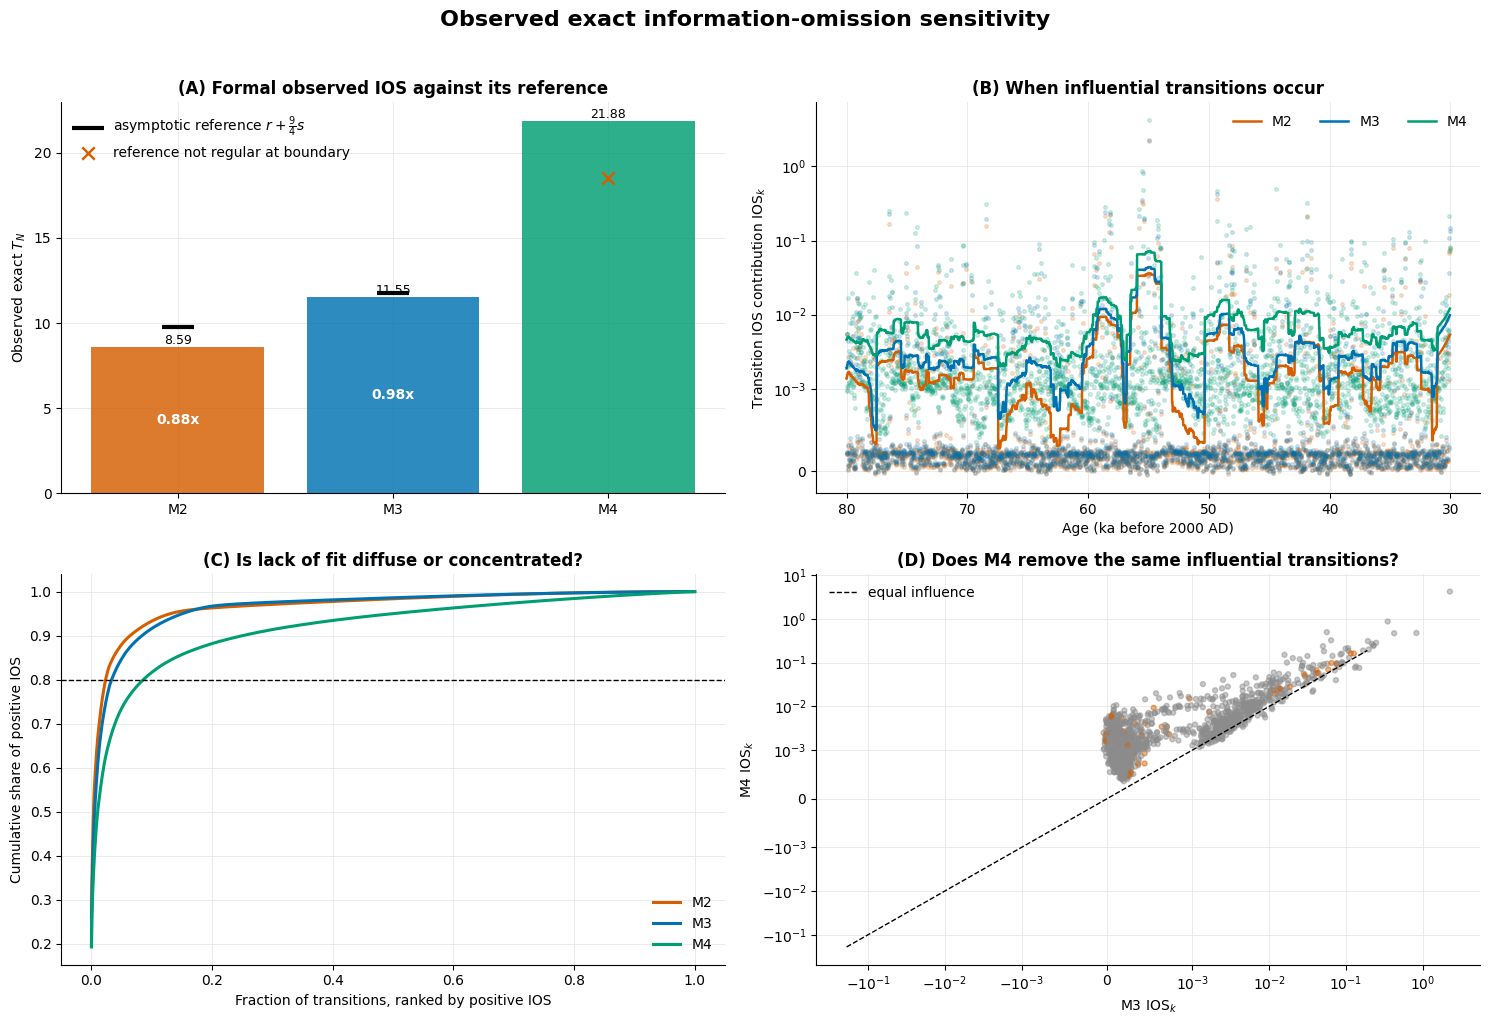

In [24]:
ios_transitions = pd.read_csv(CURRENT / "ios_transitions.csv")
plot_ios_overview(ios_summary, ios_transitions)
plt.show()


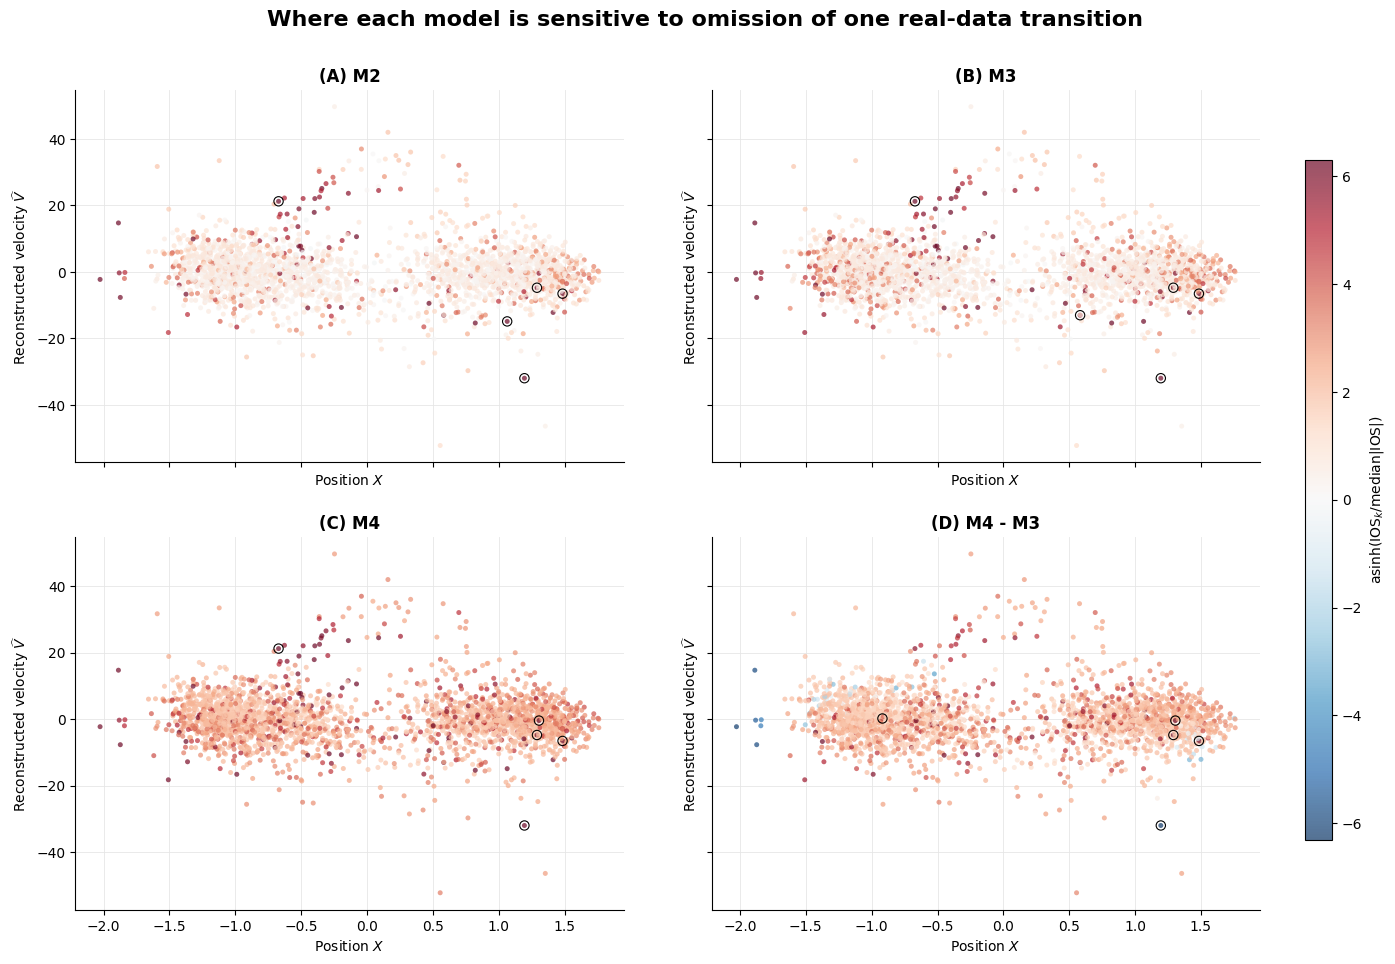

In [25]:
plot_ios_phase_space(ios_transitions)
plt.show()


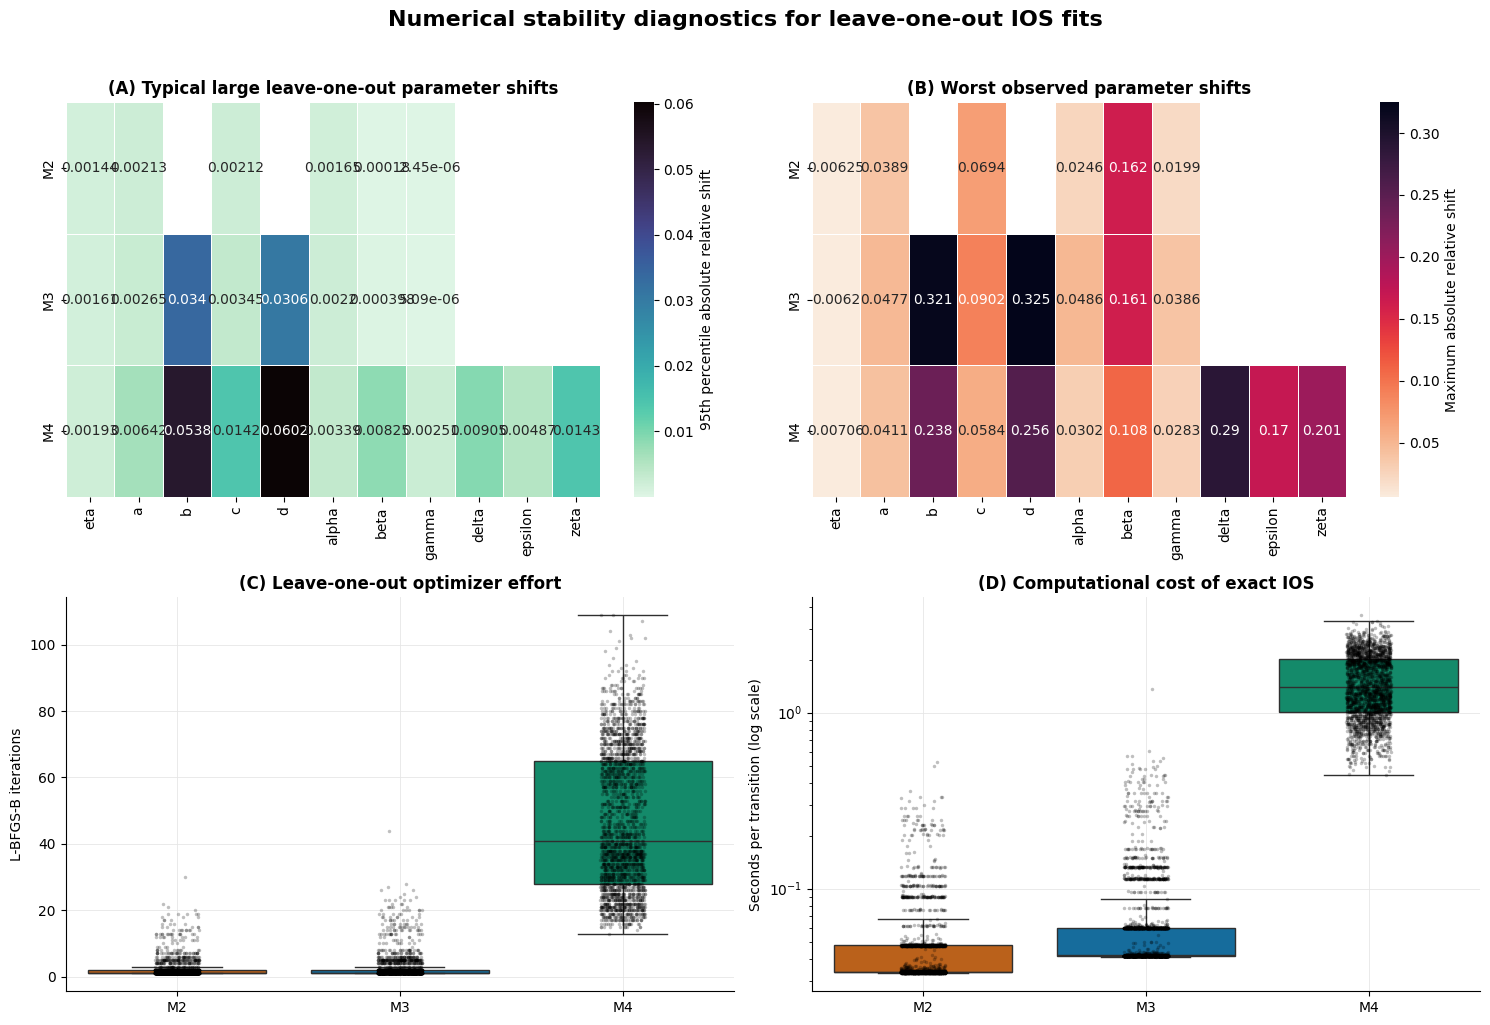

In [26]:
plot_ios_numerical_diagnostics(
    pd.read_csv(CURRENT / "ios_parameter_shifts.csv"),
    ios_transitions,
)
plt.show()


## 8. Model-wise M4 IOS bootstrap

Each replication simulates from fitted M4, refits M4, and recomputes all 2499
leave-one-out fits. This calibrates the IOS statistic under the full current
estimation pipeline.


In [27]:
modelwise_summary = pd.read_csv(
    CURRENT / "m4_modelwise_ios_bootstrap_summary.csv"
)
modelwise_summary.round(4)


,model,observed_T_N,n_total,n_success,n_failed,success_rate,mean,sd,q025,q50,q975,p_upper,p_lower,observed_percentile,median_time_sec,total_time_sec,median_ios_seconds
0,M4,21.8765,200,200,0,1.0,50.6782,37.8945,21.0893,39.8286,154.8007,0.9652,0.0398,0.035,3219.3252,678314.4388,3130.3531


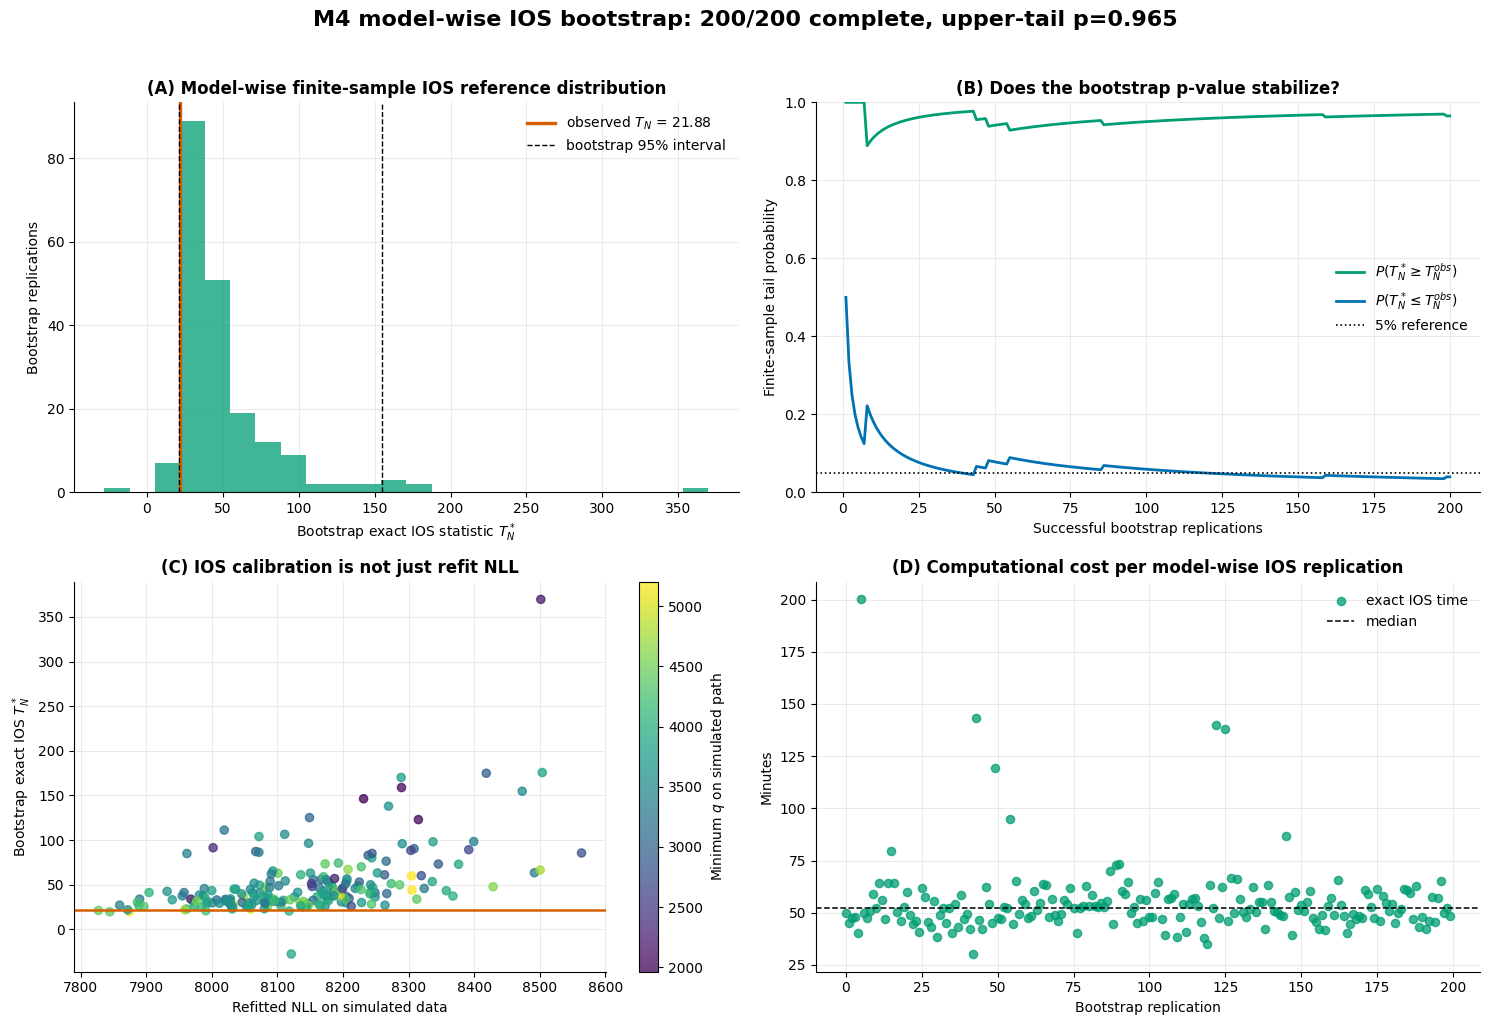

In [28]:
plot_modelwise_ios_bootstrap(
    modelwise_summary,
    pd.read_csv(CURRENT / "m4_modelwise_ios_bootstrap_cumulative.csv"),
    pd.read_csv(CURRENT / "m4_modelwise_ios_bootstrap.csv"),
)
plt.show()


## 9. Current conclusion

The current evidence shows that M4 is numerically viable, improves the
real-data objective, changes the fitted diffusion over observed phase space,
and does not have unusually large IOS under its own bootstrap calibration.

The predictive simulations still switch more often than the observed path,
and the position distribution remains too narrow. M4 therefore improves the
local likelihood without solving every model-check discrepancy.

M4 has not yet been formally selected over M3. The next required experiment
is the M3-null nested bootstrap using the current Cholesky optimizer. Repeated
recovery and discrimination should then be rerun with the same optimizer.


## 10. Reproducibility commands

```bash
python3 -m greenland_application.run_report_assets --refresh-snapshot
quarto render docs/M4_GREENLAND_RESEARCH_REPORT.md --to html
quarto render docs/M4_GREENLAND_RESEARCH_REPORT.md --to pdf
python3 -m unittest discover tests -v
```
